# PHÂN TÍCH CÁC THÀNH PHẦN CHÍNH TRONG DỮ LIỆU CHUỖI THỜI GIAN

## 1. Dữ liệu thời gian là gì? Các thành phần cấu tạo
**Dữ liệu chuỗi thời gian (Time Series Data)** là một tập hợp các quan sát được ghi nhận liên tiếp theo các khoảng thời gian đều đặn (ví dụ: mỗi giờ, mỗi ngày, mỗi tháng). Sự khác biệt lớn nhất của nó so với dữ liệu bảng thông thường là thứ tự thời gian mang ý nghĩa quyết định, dữ liệu hôm nay có sự liên kết và phụ thuộc vào dữ liệu ngày hôm qua.

Theo lý thuyết Decomposition, một điểm dữ liệu thời gian ($Y_t$) tại thời điểm $t$ luôn được cấu thành từ 3 thành phần chính:

* **Mô hình cộng:** Dùng khi biên độ dao động ổn định theo thời gian.
  $$Data = Trend + Seasonality + Noise \quad (Y_t = T_t + S_t + R_t)$$
* **Mô hình nhân:** Dùng khi biên độ dao động phình to hoặc thu hẹp tỷ lệ thuận với xu hướng.
  $$Data = Trend \times Seasonality \times Noise \quad (Y_t = T_t \times S_t \times R_t)$$


---

## 2. Làm rõ các thành phần: Trend, Seasonality và Noise

### Bảng So sánh Tổng kết

| Tiêu chí | Trend | Seasonality | Noise / Residual |
| :--- | :--- | :--- | :--- |
| **Định nghĩa** | Sự dịch chuyển tổng thể của dữ liệu (Tăng, Giảm, hoặc Đi ngang) trong một khoảng thời gian dài. | Những biến động lặp đi lặp lại có chu kỳ với tần suất cố định (theo ngày trong tuần, tháng trong năm). | Các biến động ngẫu nhiên, bất thường, phần còn sót lại sau khi đã tách Trend và Seasonality. |
| **Tính quy luật** | Có thể nhận diện được đường xu hướng dài hạn. | Quy luật lặp lại rất rõ ràng và dễ đoán trước. | Hoàn toàn ngẫu nhiên, không có quy luật. |
| **Khoảng thời gian** | Dài hạn (Vài tháng đến vài năm). | Ngắn hạn, có chu kỳ cố định (Ví dụ: 7 ngày/tuần). | Bất chợt, tức thời. |
| **Ví dụ trong Covid-19** | Làn sóng dịch thứ 4 làm số ca nhiễm **tăng vọt liên tục** từ tháng 5 đến tháng 9/2021. | Số ca báo cáo thường **giảm mạnh vào Chủ nhật** (do nhân viên y tế nghỉ) và **tăng vọt vào thứ 3** (khi báo cáo bù). | Một ngày đột nhiên tăng 50.000 ca do một tỉnh **tổng hợp dữ liệu báo cáo dồn** hoặc có ổ dịch mới bùng phát bất ngờ. |

---

## 3. Mục tiêu của việc bóc tách thành phần (Áp dụng vào dữ liệu Covid)

Việc dùng thuật toán để phân rã tập dữ liệu thành 3 thành phần trên có thể đạt được nhiều lợi ích, có thể nói lợi mà nó mang lại những **thông tin hỗ trợ Insight** trong chống dịch:

1. **Tìm ra Trend:** 
   * *Mục tiêu:* Bỏ qua những trồi sụt hàng ngày để nhìn thấy bức tranh toàn cảnh.
   * *Quyết định:* Giúp Chính phủ đánh giá xem "Làn sóng dịch đang phình to ra hay đã đạt đỉnh và bắt đầu thoái trào?". Từ đó quyết định nới lỏng hay siết chặt lệnh giãn cách xã hội.
2. **Tìm ra Seasonality:**
   * *Mục tiêu:* Hiểu được thói quen ghi nhận dữ liệu hoặc chu kỳ sinh học.
   * *Quyết định:* Nếu biết chắc chắn Chủ nhật số ca sẽ báo cáo thấp và dồn lên cao vào đầu tuần, Bộ Y tế sẽ không bị quá tải khi thấy ca nhiễm tăng vọt vào thứ 3, đồng thời điều phối nhân sự trực tổng đài Y tế hợp lý theo các ngày trong tuần.
3. **Tìm ra Noise:**
   * *Mục tiêu:* Phát hiện các dị thường không thể giải thích bằng xu hướng hay chu kỳ.
   * *Quyết định:* Nếu đường Noise đột ngột vượt ngưỡng an toàn, đó có thể là tín hiệu cảnh báo sự xuất hiện của một biến chủng Covid mới (như Delta hay Omicron) có tốc độ lây lan vượt khỏi quy luật cũ, hoặc phát hiện ra sai sót trong nhập liệu của một địa phương để yêu cầu đính chính.

---

## 4. Time Plot khác gì với Line Plot?

Tuy nhìn bề ngoài rất giống nhau (đều là biểu đồ đường), nhưng **Time Plot (Biểu đồ chuỗi thời gian)** là một phiên bản đặc biệt và cụ thể hơn của **Line Plot (Biểu đồ đường)**.

| Tiêu chí | Line Plot (Biểu đồ đường) | Time Plot (Biểu đồ thời gian) |
| :--- | :--- | :--- |
| **Trục X** | Có thể là bất kỳ biến liên tục nào (Tuổi tác, Chi phí, Nhiệt độ...). | Bắt buộc phải là trục Thời gian (Date, Time) và được sắp xếp nghiêm ngặt từ quá khứ đến hiện tại. |
| **Trục Y** | Sự phụ thuộc của Y vào X. | Giá trị của biến quan sát tại thời điểm t. |
| **Mục đích phân tích** | Tìm mối tương quan, sự biến thiên giữa 2 biến số bất kỳ. | Khám phá xu hướng (Trend), chu kỳ lặp lại (Seasonality) của một biến theo thời gian. |
| **Bản chất dữ liệu** | Các điểm dữ liệu trên trục X có thể xáo trộn ngẫu nhiên mà không làm sai lệch bản chất tương quan. | **Không được phép xáo trộn.** Nếu tráo đổi vị trí các ngày cho nhau, toàn bộ ý nghĩa của chuỗi thời gian sẽ bị phá vỡ hoàn toàn. |

In [1]:
import os
import sys

# Thêm src vào Python path để import module time_series
for src_path in (os.path.abspath("../src"), os.path.abspath("src")):
    if os.path.isdir(src_path) and src_path not in sys.path:
        sys.path.append(src_path)

from time_series.dataset import TimeSeriesDataset
from time_series.analysis_data_components import AnalysisDataTimeComponents

# Nạp dữ liệu
dataset_path = "../data/time_series/time-series-19-covid-combined.csv"
print(f"[INFO] Đang nạp dữ liệu từ: {dataset_path}")
ts_data = TimeSeriesDataset(path=dataset_path, time_column="Date")

[INFO] Đang nạp dữ liệu từ: ../data/time_series/time-series-19-covid-combined.csv
[Time Series Mode] Đã nạp và sắp xếp dữ liệu theo 'Date'.


[EXECUTE] Đang vẽ Time Plot cho biến 'Confirmed' tại 'US'...


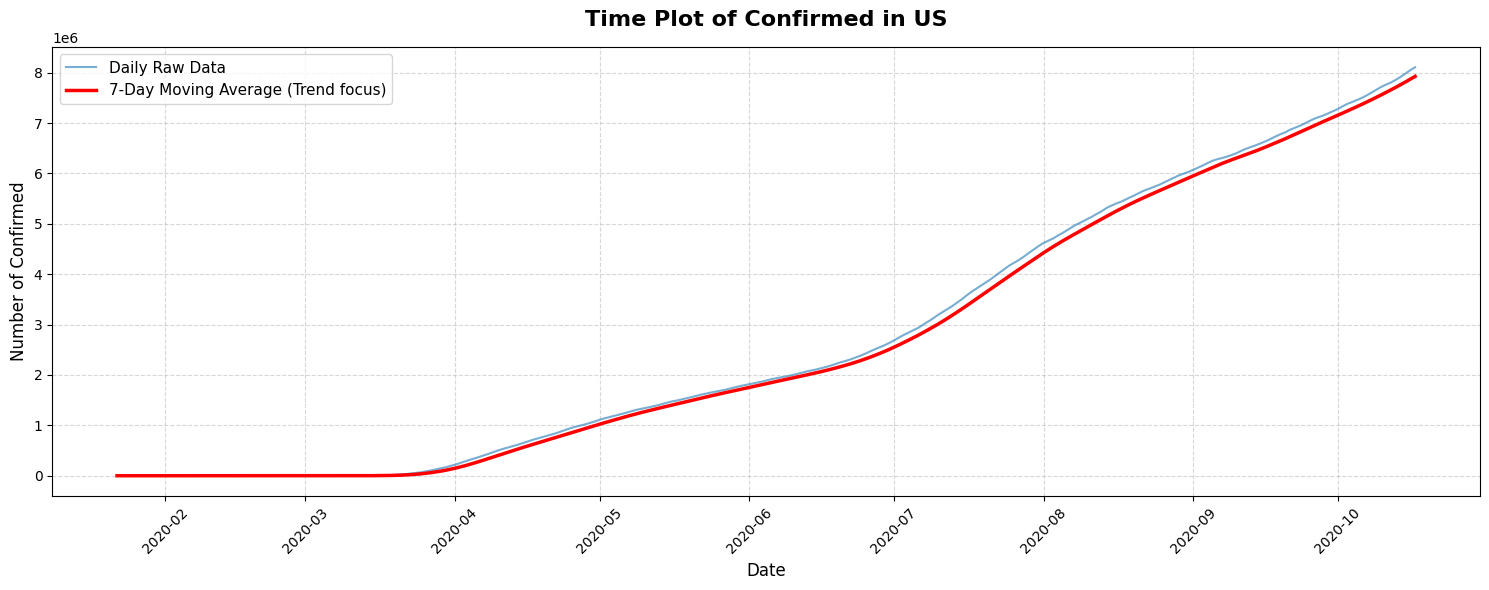

In [2]:
# 4. Khởi tạo chức năng phân tích (Ví dụ khảo sát số ca nhiễm ở Mỹ)
analyzer = AnalysisDataTimeComponents(region="US", feature_name="Confirmed")

# 5. Chạy lệnh trực quan hóa
analyzer.run(ts_data)

## 5. Phân tích và Nhận xét trực quan: Biến `Confirmed` (Ca nhiễm - US)

**Mục tiêu:** Trực quan hóa biến `Confirmed` (Tổng số ca nhiễm tích lũy) tại Mỹ (US) từ tháng 1 đến tháng 10/2020 nhằm đánh giá bức tranh tổng thể về tốc độ lây lan của đại dịch.

**1. Đánh giá thành phần Trending:**
* **Chiều hướng:** Dữ liệu có xu hướng **tăng liên tục** theo thời gian (đặc trưng của số liệu cộng dồn).
* **Biến động xu hướng:** 
  * *T2 - T3/2020:* Đi ngang (Giai đoạn ủ bệnh, lây lan ngầm).
  * *T4 - T6/2020:* Bắt đầu dốc lên (Làn sóng lây nhiễm thứ nhất).
  * *T7 - T10/2020:* Đường cong dốc đứng cực mạnh (Làn sóng bùng phát thứ hai).

**2. Đánh giá thành phần Seasonality:**
* **Biểu hiện:** Hoàn toàn không quan sát thấy dấu hiệu lặp lại có chu kỳ trên biểu đồ này. 
* **Lý do:** Con số tích lũy khổng lồ (lên tới 8 triệu ca) đã che lấp hoàn toàn những gợn sóng chu kỳ báo cáo nhỏ lẻ theo ngày/tuần.

**3. Đánh giá thành phần Noise:**
* **Biểu hiện:** Biến này **rất ít nhiễu**. Đường dữ liệu gốc (Raw Data) và đường 7-Day Moving Average gần như **chồng khít lên nhau**, không có các gai nhọn bất thường.

**Kết luận:** Sự thiếu vắng của Noise và Seasonality trên biểu đồ tích lũy chứng tỏ sức lây lan của virus là liên tục và ổn định ở mức cao. Để phân tích được tính chu kỳ (VD: số ca thường tăng vào thứ mấy trong tuần) hoặc tìm các điểm bất thường, ta bắt buộc phải tính sai phân để chuyển dữ liệu về dạng "Số ca mắc mới mỗi ngày.

[INFO] Đã chuyển biến khảo sát sang: Deaths
[EXECUTE] Đang vẽ Time Plot cho biến 'Deaths' tại 'US'...


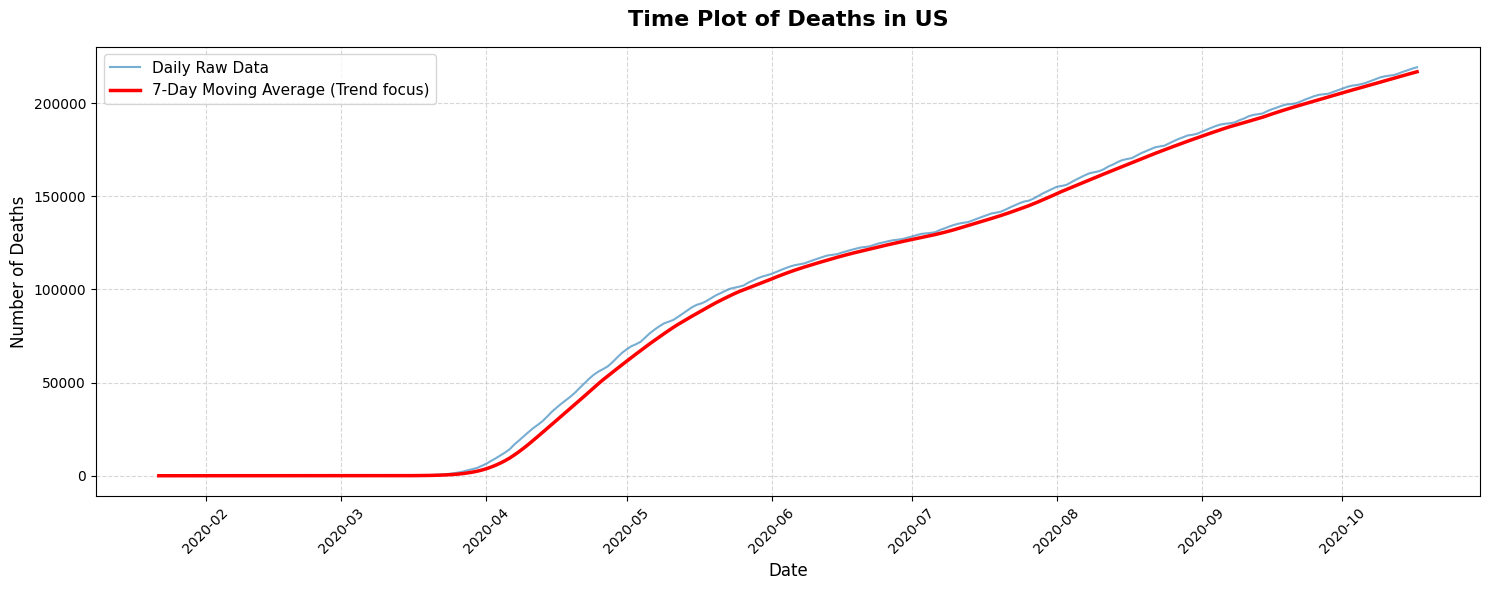

In [3]:
# Đổi sang biến Deaths và vẽ
analyzer.change_feature("Deaths", ts_data.columns)
analyzer.run(ts_data)

## Phân tích và Nhận xét trực quan: Biến `Deaths` (Tử vong - US)

**Mục tiêu:** Trực quan hóa biến `Deaths` (Tổng số ca tử vong cộng dồn) tại Mỹ (US) nhằm đánh giá mức độ nghiêm trọng của dịch bệnh và năng lực cứu chữa của hệ thống y tế.

**1. Đánh giá thành phần Trending:**
* **Chiều hướng:** Xu hướng **tăng liên tục** nhưng có dạng hình chữ S (Sigmoidal curve) kéo dài.
* **Biến động xu hướng:**
  * *T4 - T5/2020:* Dốc lên cực kỳ nhanh, phản ánh sự quá tải y tế và tỷ lệ tử vong cao ở giai đoạn đầu bùng dịch.
  * *T6 - T8/2020:* Đường cong **tăng thoai thoải dần**. Tốc độ tăng đã chậm lại rõ rệt.

**2. Đánh giá thành phần Seasonality & Noise:**
* Tương tự biến `Confirmed`, do là dữ liệu tích lũy lớn, biến `Deaths` **không thể hiện tính chu kỳ (Seasonality)** và có **rất ít nhiễu (Noise)**. Hai đường biểu diễn bám rất sát nhau.

**Kết luận:** Nếu đối chiếu với biểu đồ `Confirmed`, ta thấy một tín hiệu tích cực: Dù số ca nhiễm (Confirmed) vẫn tăng dốc đứng ở làn sóng thứ 2 (T7-T10), nhưng số ca tử vong (Deaths) lại tăng chậm lại. Điều này chứng tỏ năng lực y tế đã được cải thiện, phác đồ điều trị tốt hơn giúp ghìm cương được tỷ lệ tử vong.

[INFO] Đã chuyển biến khảo sát sang: Recovered
[EXECUTE] Đang vẽ Time Plot cho biến 'Recovered' tại 'US'...


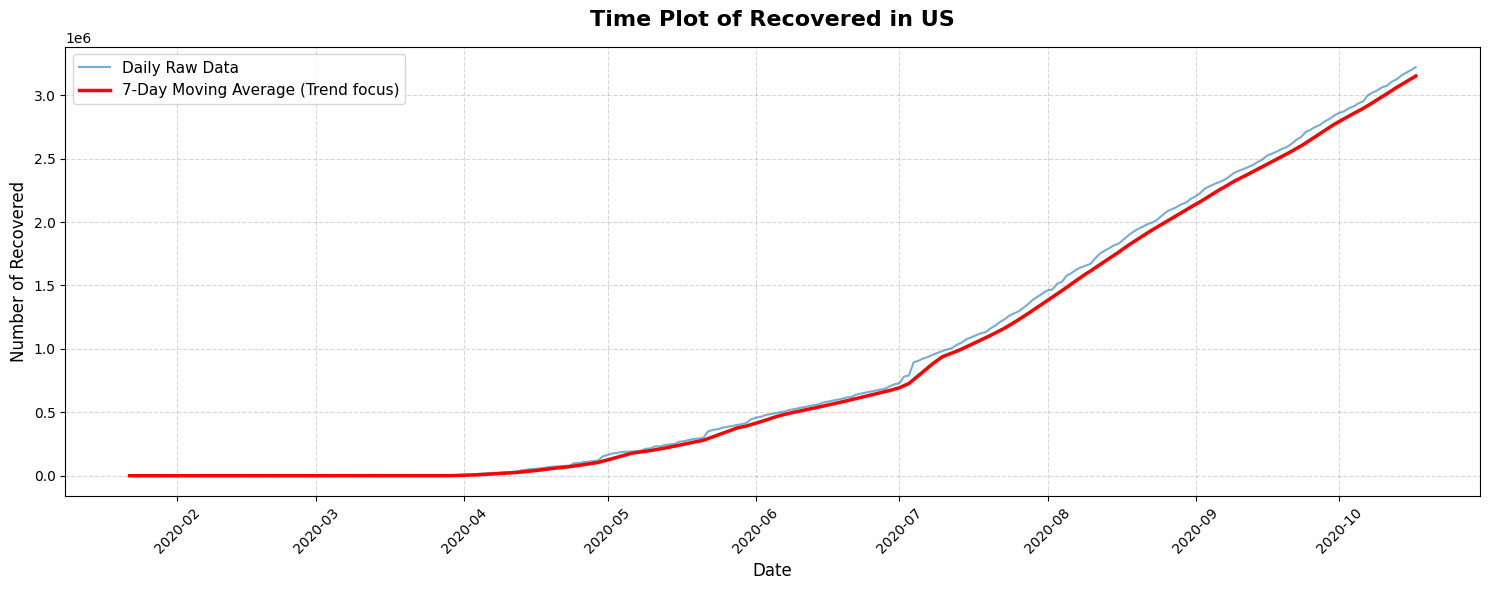

In [4]:
# Đổi sang biến Recovered và vẽ
analyzer.change_feature("Recovered", ts_data.columns)
analyzer.run(ts_data)

## Phân tích và Nhận xét trực quan: Biến `Recovered` (Phục hồi - US)

**Mục tiêu:** Trực quan hóa biến `Recovered` (Tổng số ca phục hồi cộng dồn) tại Mỹ (US) nhằm đánh giá khả năng kiểm soát thiệt hại của hệ thống y tế.

**1. Đánh giá thành phần Trending:**
* **Chiều hướng:** Xu hướng **tăng liên tục**, dốc lên tỷ lệ thuận với số ca nhiễm bệnh.
* **Biến động xu hướng:** Tăng chậm từ T1-T5/2020, sau đó **tăng vọt và dốc đứng** từ T6/2020 trở đi.

**2. Đánh giá thành phần Seasonality:**
* **Biểu hiện:** Không có quy luật lặp lại chu kỳ thống nhất.

**3. Đánh giá thành phần Noise:**
* **Biểu hiện:** Biến này **có nhiễu rõ ràng nhất** trong 3 biến. 
* **Phân tích chi tiết Nhiễu:**
  * Từ T7/2020 trở đi, đường Raw Data bắt đầu gợn sóng và tách rời khỏi đường Moving Average.
  * Xuất hiện các điểm tăng/giảm bậc thang đột ngột (VD: Đầu tháng 7 có 1 điểm dữ liệu tăng vọt, sau đó lại đi ngang).

**Kết luận:** Dữ liệu `Recovered` mang lại 2 góc nhìn: (1) Tích cực: Tốc độ phục hồi đang tăng rất nhanh. (2) Tiêu cực về mặt Dữ liệu: Sự xuất hiện của nhiều nhiễu phản ánh hiện tượng **Data Dumping**. Các cơ sở y tế có thể đã không cập nhật số ca khỏi bệnh mỗi ngày, mà dồn lại một cục để báo cáo vào một ngày nhất định, khiến dữ liệu bị giật cục và thiếu đồng bộ so với hệ thống đếm ca nhiễm/tử vong.